### import all the libraries that we will use throughout the project

In [1]:
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from xgboost import XGBClassifier

warnings.filterwarnings("ignore")

# Create results folder
os.makedirs("results", exist_ok=True)

print("Libraries imported successfully.")

Libraries imported successfully.


### load available files from input

In [2]:
for dirname, _, filenames in os.walk("/kaggle/input"):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/devikshah/health-symptoms-and-disease-prediction-dataset/LICENSE.txt.txt
/kaggle/input/datasets/devikshah/health-symptoms-and-disease-prediction-dataset/training.csv


### load appropiate dataset

In [3]:
df = pd.read_csv(
    "/kaggle/input/datasets/devikshah/health-symptoms-and-disease-prediction-dataset/training.csv"
)

print("Dataset loaded successfully.")
print("Shape:", df.shape)

display(df.head())

Dataset loaded successfully.
Shape: (4924, 136)


,itching,skin_rash,nodal_skin_eruptions,continuous_sneezing,shivering,chills,joint_pain,stomach_pain,acidity,ulcers_on_tongue,...,silver_like_dusting,small_dents_in_nails,inflammatory_nails,blister,red_sore_around_nose,yellow_crust_ooze,Urinating_a_lot,Heartburn,prognosis,medicine
0,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Fungal infection,"Topical antifungals, oral antifungals"
1,0,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Fungal infection,"Topical antifungals, oral antifungals"
2,1,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Fungal infection,"Topical antifungals, oral antifungals"
3,1,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Fungal infection,"Topical antifungals, oral antifungals"
4,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Fungal infection,"Topical antifungals, oral antifungals"


### dataset inspection

In [4]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes.value_counts())

print("\nDataset information:")
df.info()

Number of rows: 4924
Number of columns: 136

Column names:
['itching', 'skin_rash', 'nodal_skin_eruptions', 'continuous_sneezing', 'shivering', 'chills', 'joint_pain', 'stomach_pain', 'acidity', 'ulcers_on_tongue', 'muscle_wasting', 'vomiting', 'burning_micturition', 'spotting_ urination', 'fatigue', 'weight_gain', 'anxiety', 'cold_hands_and_feets', 'mood_swings', 'weight_loss', 'restlessness', 'lethargy', 'patches_in_throat', 'irregular_sugar_level', 'cough', 'high_fever', 'sunken_eyes', 'breathlessness', 'sweating', 'dehydration', 'indigestion', 'headache', 'yellowish_skin', 'dark_urine', 'nausea', 'loss_of_appetite', 'pain_behind_the_eyes', 'back_pain', 'constipation', 'abdominal_pain', 'diarrhoea', 'mild_fever', 'yellow_urine', 'yellowing_of_eyes', 'acute_liver_failure', 'fluid_overload', 'swelling_of_stomach', 'swelled_lymph_nodes', 'malaise', 'blurred_and_distorted_vision', 'phlegm', 'throat_irritation', 'redness_of_eyes', 'sinus_pressure', 'runny_nose', 'congestion', 'chest_pain

int64     134
object      2
Name: count, dtype: int64


Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4924 entries, 0 to 4923
Columns: 136 entries, itching to medicine
dtypes: int64(134), object(2)
memory usage: 5.1+ MB


### check missing values

In [5]:
missing_values = df.isnull().sum()

print("Missing values:")
display(missing_values[missing_values > 0])

print("\nTotal missing values:", missing_values.sum())

Missing values:


Series([], dtype: int64)


Total missing values: 0


### check duplicate rows & remove if any

In [6]:
duplicate_count = df.duplicated().sum()
print("Duplicate rows:", duplicate_count)

if duplicate_count > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print(f"Removed {duplicate_count} duplicate rows.")
else:
    print("No duplicate rows to remove.")

print("New dataset shape:", df.shape)

Duplicate rows: 4616
Removed 4616 duplicate rows.
New dataset shape: (308, 136)


### target column

In [7]:
target_column = "prognosis"

print("Target column:", target_column)

print("\nNumber of disease classes:")
print(df[target_column].nunique())

print("\nDisease names:")
print(df[target_column].unique())

Target column: prognosis

Number of disease classes:
43

Disease names:
['Fungal infection' 'Allergy' 'GERD' 'Chronic cholestasis' 'Drug Reaction'
 'Peptic ulcer diseae' 'AIDS' 'Diabetes ' 'Gastroenteritis'
 'Bronchial Asthma' 'Hypertension ' 'Migraine' 'Cervical spondylosis'
 'Paralysis (brain hemorrhage)' 'Jaundice' 'Malaria' 'Chicken pox'
 'Dengue' 'Typhoid' 'hepatitis A' 'Hepatitis B' 'Hepatitis C'
 'Hepatitis D' 'Hepatitis E' 'Alcoholic hepatitis' 'Tuberculosis'
 'Common Cold' 'Pneumonia' 'Dimorphic hemmorhoids(piles)' 'Heart attack'
 'Varicose veins' 'Hypothyroidism' 'Hyperthyroidism' 'Hypoglycemia'
 'Osteoarthristis' 'Arthritis' '(vertigo) Paroymsal  Positional Vertigo'
 'Acne' 'Urinary tract infection' 'Psoriasis' 'Impetigo' 'Diabetes'
 'Chikungunya']


### visualise disease distribution

In [8]:
class_counts = df[target_column].value_counts()

print("Disease distribution:")
display(class_counts)

Disease distribution:


prognosis
Dengue                                     11
Migraine                                   10
Chicken pox                                10
Hepatitis D                                10
hepatitis A                                 9
Typhoid                                     9
Malaria                                     9
Jaundice                                    9
Diabetes                                    9
Tuberculosis                                9
Common Cold                                 9
Hyperthyroidism                             9
Hypoglycemia                                9
Hepatitis B                                 9
Hepatitis E                                 9
Pneumonia                                   9
Varicose veins                              8
Hypothyroidism                              8
Alcoholic hepatitis                         8
Chronic cholestasis                         8
GERD                                        7
Hepatitis C             

### find rare disease

In [9]:
print("Diseases with fewer than 5 samples:")

rare_classes = class_counts[class_counts < 5]

display(rare_classes)

print("Number of rare disease classes:", len(rare_classes))

Diseases with fewer than 5 samples:


prognosis
Diabetes       1
Chikungunya    1
Name: count, dtype: int64

Number of rare disease classes: 2


### find rare classes

In [10]:
MIN_SAMPLES = 5

before_rows = len(df)
before_classes = df[target_column].nunique()

class_counts = df[target_column].value_counts()

valid_classes = class_counts[
    class_counts >= MIN_SAMPLES
].index

df = df[
    df[target_column].isin(valid_classes)
].copy()

df = df.reset_index(drop=True)

after_rows = len(df)
after_classes = df[target_column].nunique()

print("Rare-class filtering completed.")
print("--------------------------------")
print("Minimum samples required:", MIN_SAMPLES)
print("Rows before:", before_rows)
print("Rows after:", after_rows)
print("Rows removed:", before_rows - after_rows)
print("Diseases before:", before_classes)
print("Diseases after:", after_classes)
print("Diseases removed:", before_classes - after_classes)

Rare-class filtering completed.
--------------------------------
Minimum samples required: 5
Rows before: 308
Rows after: 306
Rows removed: 2
Diseases before: 43
Diseases after: 41
Diseases removed: 2


### verify filtering

In [11]:
class_counts = df[target_column].value_counts()

print("Disease distribution after filtering:")
display(class_counts)

print(
    "Minimum samples in remaining classes:",
    class_counts.min()
)

Disease distribution after filtering:


prognosis
Dengue                                     11
Chicken pox                                10
Hepatitis D                                10
Migraine                                   10
Typhoid                                     9
Malaria                                     9
Jaundice                                    9
hepatitis A                                 9
Diabetes                                    9
Hepatitis B                                 9
Hepatitis E                                 9
Common Cold                                 9
Hypoglycemia                                9
Hyperthyroidism                             9
Pneumonia                                   9
Tuberculosis                                9
Chronic cholestasis                         8
Varicose veins                              8
Hypothyroidism                              8
Alcoholic hepatitis                         8
(vertigo) Paroymsal  Positional Vertigo     7
Bronchial Asthma        

Minimum samples in remaining classes: 5


### visualise disease distribution

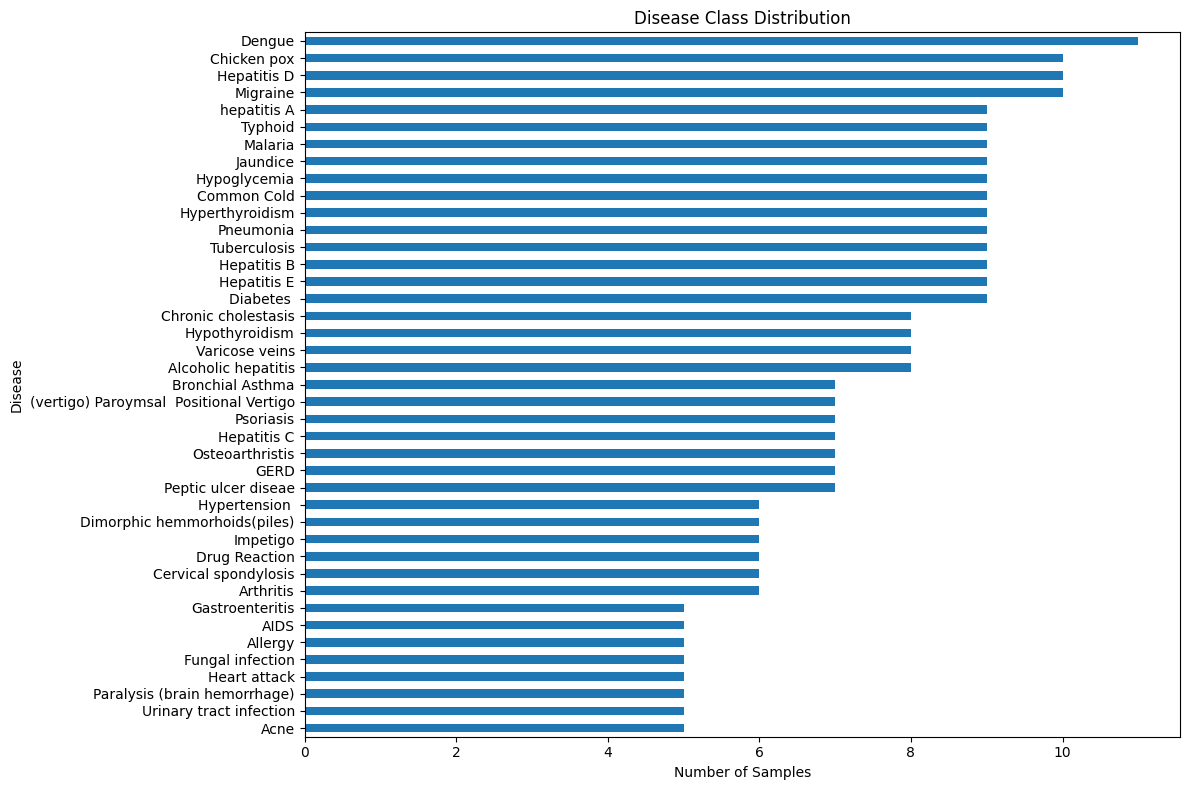

In [12]:
plt.figure(figsize=(12, 8))

class_counts.sort_values().plot(
    kind="barh"
)

plt.title("Disease Class Distribution")
plt.xlabel("Number of Samples")
plt.ylabel("Disease")

plt.tight_layout()

plt.savefig(
    "results/target_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### separte features & target

In [13]:
# Target column
target_column = "prognosis"

# Separate target from features
X_all = df.drop(columns=[target_column])
y = df[target_column]

print("All feature columns:", X_all.shape[1])
print("Target shape:", y.shape)

print("\nFeature data types:")
display(X_all.dtypes.value_counts())

All feature columns: 135
Target shape: (306,)

Feature data types:


int64     134
object      1
Name: count, dtype: int64

### identify numeric and non-numeric columns

In [14]:
# Find numeric columns
numeric_columns = X_all.select_dtypes(
    include=np.number
).columns.tolist()

# Find non-numeric columns
non_numeric_columns = X_all.select_dtypes(
    exclude=np.number
).columns.tolist()

print("Number of numeric features:", len(numeric_columns))
print("Number of non-numeric features:", len(non_numeric_columns))

print("\nNon-numeric columns:")
for column in non_numeric_columns:
    print("-", column)

Number of numeric features: 134
Number of non-numeric features: 1

Non-numeric columns:
- medicine


### use only numeric symptom features

In [15]:
X = X_all[numeric_columns].copy()

print("Final feature matrix shape:", X.shape)

print("\nFinal feature columns:")
print(X.columns.tolist())

Final feature matrix shape: (306, 134)

Final feature columns:
['itching', 'skin_rash', 'nodal_skin_eruptions', 'continuous_sneezing', 'shivering', 'chills', 'joint_pain', 'stomach_pain', 'acidity', 'ulcers_on_tongue', 'muscle_wasting', 'vomiting', 'burning_micturition', 'spotting_ urination', 'fatigue', 'weight_gain', 'anxiety', 'cold_hands_and_feets', 'mood_swings', 'weight_loss', 'restlessness', 'lethargy', 'patches_in_throat', 'irregular_sugar_level', 'cough', 'high_fever', 'sunken_eyes', 'breathlessness', 'sweating', 'dehydration', 'indigestion', 'headache', 'yellowish_skin', 'dark_urine', 'nausea', 'loss_of_appetite', 'pain_behind_the_eyes', 'back_pain', 'constipation', 'abdominal_pain', 'diarrhoea', 'mild_fever', 'yellow_urine', 'yellowing_of_eyes', 'acute_liver_failure', 'fluid_overload', 'swelling_of_stomach', 'swelled_lymph_nodes', 'malaise', 'blurred_and_distorted_vision', 'phlegm', 'throat_irritation', 'redness_of_eyes', 'sinus_pressure', 'runny_nose', 'congestion', 'chest_

### check feature values

In [16]:
print("Feature data types:")
display(X.dtypes.value_counts())

print("\nUnique values in features:")

unique_values = {}

for column in X.columns:
    unique_values[column] = X[column].unique()[:10]

display(
    pd.DataFrame.from_dict(
        unique_values,
        orient="index"
    ).head(20)
)

Feature data types:


int64    134
Name: count, dtype: int64


Unique values in features:


,0,1
itching,1,0.0
skin_rash,1,0.0
nodal_skin_eruptions,1,0.0
continuous_sneezing,0,1.0
shivering,0,1.0
chills,0,1.0
joint_pain,0,1.0
stomach_pain,0,1.0
acidity,0,1.0
ulcers_on_tongue,0,1.0


### encode disease labels

In [17]:
label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

print("Target encoded successfully.")

print("\nDisease label mapping:")

label_mapping = pd.DataFrame({
    "Encoded Label": range(len(label_encoder.classes_)),
    "Disease": label_encoder.classes_
})

display(label_mapping)

Target encoded successfully.

Disease label mapping:


,Encoded Label,Disease
0,0,(vertigo) Paroymsal Positional Vertigo
1,1,AIDS
2,2,Acne
3,3,Alcoholic hepatitis
4,4,Allergy
5,5,Arthritis
6,6,Bronchial Asthma
7,7,Cervical spondylosis
8,8,Chicken pox
9,9,Chronic cholestasis


### final class safety check

In [18]:
encoded_class_counts = pd.Series(
    y_encoded
).value_counts()

print("Encoded class distribution:")
display(encoded_class_counts.sort_index())

minimum_class_size = encoded_class_counts.min()

print(
    "\nSmallest class contains:",
    minimum_class_size,
    "samples."
)

if minimum_class_size < 2:
    raise ValueError(
        "A class still has fewer than 2 samples. "
        "Increase MIN_SAMPLES."
    )

print("\n✓ Stratified train/test split is possible.")

Encoded class distribution:


0      7
1      5
2      5
3      8
4      5
5      6
6      7
7      6
8     10
9      8
10     9
11    11
12     9
13     6
14     6
15     5
16     7
17     5
18     5
19     9
20     7
21    10
22     9
23     6
24     9
25     9
26     8
27     6
28     9
29     9
30    10
31     7
32     5
33     7
34     9
35     7
36     9
37     9
38     5
39     8
40     9
Name: count, dtype: int64


Smallest class contains: 5 samples.

✓ Stratified train/test split is possible.


### train/test data split (80/20)

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

print("Train/Test split completed successfully.")

print("\nTraining set:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("\nTesting set:")
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

Train/Test split completed successfully.

Training set:
X_train: (244, 134)
y_train: (244,)

Testing set:
X_test: (62, 134)
y_test: (62,)


### verify train/test distribution

In [20]:
train_distribution = pd.Series(
    y_train
).value_counts().sort_index()

test_distribution = pd.Series(
    y_test
).value_counts().sort_index()

distribution_check = pd.DataFrame({
    "Disease": label_encoder.classes_,
    "Training Samples": train_distribution.values,
    "Testing Samples": test_distribution.values
})

display(distribution_check)

,Disease,Training Samples,Testing Samples
0,(vertigo) Paroymsal Positional Vertigo,6,1
1,AIDS,4,1
2,Acne,4,1
3,Alcoholic hepatitis,6,2
4,Allergy,4,1
5,Arthritis,5,1
6,Bronchial Asthma,6,1
7,Cervical spondylosis,5,1
8,Chicken pox,8,2
9,Chronic cholestasis,6,2


### define ml models

In [21]:
models = {
    "Logistic Regression": Pipeline([
        (
            "scaler",
            StandardScaler()
        ),
        (
            "model",
            LogisticRegression(
                max_iter=2000,
                random_state=42
            )
        )
    ]),

    "SVM": Pipeline([
        (
            "scaler",
            StandardScaler()
        ),
        (
            "model",
            SVC(
                kernel="linear",
                probability=True,
                random_state=42
            )
        )
    ]),

    "Gaussian Naive Bayes": GaussianNB(),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),

    "XGBoost": XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="mlogloss",
        random_state=42
    )
}

print("Models:")
for model_name in models:
    print("-", model_name)

Models:
- Logistic Regression
- SVM
- Gaussian Naive Bayes
- Random Forest
- XGBoost


### train models

In [22]:
trained_models = {}

for name, model in models.items():

    print(f"\nTraining {name}...")

    model.fit(
        X_train,
        y_train
    )

    trained_models[name] = model

    print(f"✓ {name} completed.")


Training Logistic Regression...
✓ Logistic Regression completed.

Training SVM...
✓ SVM completed.

Training Gaussian Naive Bayes...
✓ Gaussian Naive Bayes completed.

Training Random Forest...
✓ Random Forest completed.

Training XGBoost...
✓ XGBoost completed.


### multiclass specificity function

In [23]:
def multiclass_specificity(y_true, y_pred):

    cm = confusion_matrix(
        y_true,
        y_pred
    )

    specificities = []

    for i in range(len(cm)):

        tp = cm[i, i]

        fn = cm[i, :].sum() - tp

        fp = cm[:, i].sum() - tp

        tn = cm.sum() - (
            tp + fn + fp
        )

        if (tn + fp) > 0:
            specificity = tn / (tn + fp)
        else:
            specificity = 0

        specificities.append(
            specificity
        )

    return np.mean(specificities)

### evaluate all models

In [24]:
results = []

predictions = {}

for name, model in trained_models.items():

    y_pred = model.predict(X_test)

    predictions[name] = y_pred

    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    precision = precision_score(
        y_test,
        y_pred,
        average="macro",
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        average="macro",
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        average="macro",
        zero_division=0
    )

    specificity = multiclass_specificity(
        y_test,
        y_pred
    )

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall / Sensitivity": recall,
        "Specificity": specificity,
        "F1-Score": f1
    })

results_df = pd.DataFrame(results)

metric_columns = [
    "Accuracy",
    "Precision",
    "Recall / Sensitivity",
    "Specificity",
    "F1-Score"
]

results_df[metric_columns] = (
    results_df[metric_columns] * 100
)

results_df = results_df.sort_values(
    "F1-Score",
    ascending=False
).reset_index(drop=True)

display(results_df)

,Model,Accuracy,Precision,Recall / Sensitivity,Specificity,F1-Score
0,Logistic Regression,100.000000,100.000000,100.000000,100.000000,100.000000
1,Random Forest,100.000000,100.000000,100.000000,100.000000,100.000000
2,Gaussian Naive Bayes,98.387097,99.186992,98.780488,99.959350,98.699187
3,XGBoost,98.387097,99.186992,98.780488,99.959350,98.699187
4,SVM,96.774194,95.934959,96.341463,99.918699,95.772358


### save model comparison

In [25]:
results_df.to_csv(
    "results/model_comparison.csv",
    index=False
)

print(
    "Saved: results/model_comparison.csv"
)

Saved: results/model_comparison.csv


### classification report

In [26]:
for name, y_pred in predictions.items():

    print("\n")
    print("=" * 80)
    print(name)
    print("=" * 80)

    print(
        classification_report(
            y_test,
            y_pred,
            target_names=label_encoder.classes_,
            zero_division=0
        )
    )



Logistic Regression
                                         precision    recall  f1-score   support

(vertigo) Paroymsal  Positional Vertigo       1.00      1.00      1.00         1
                                   AIDS       1.00      1.00      1.00         1
                                   Acne       1.00      1.00      1.00         1
                    Alcoholic hepatitis       1.00      1.00      1.00         2
                                Allergy       1.00      1.00      1.00         1
                              Arthritis       1.00      1.00      1.00         1
                       Bronchial Asthma       1.00      1.00      1.00         1
                   Cervical spondylosis       1.00      1.00      1.00         1
                            Chicken pox       1.00      1.00      1.00         2
                    Chronic cholestasis       1.00      1.00      1.00         2
                            Common Cold       1.00      1.00      1.00         2
     

### select best model

In [27]:
best_model_name = (
    results_df
    .sort_values(
        "F1-Score",
        ascending=False
    )
    .iloc[0]["Model"]
)

best_model = trained_models[
    best_model_name
]

print("Best Model:", best_model_name)

best_score = results_df.iloc[0]["F1-Score"]

print(
    "Best F1-Score:",
    f"{best_score:.2f}%"
)

Best Model: Logistic Regression
Best F1-Score: 100.00%


### model comparison chart

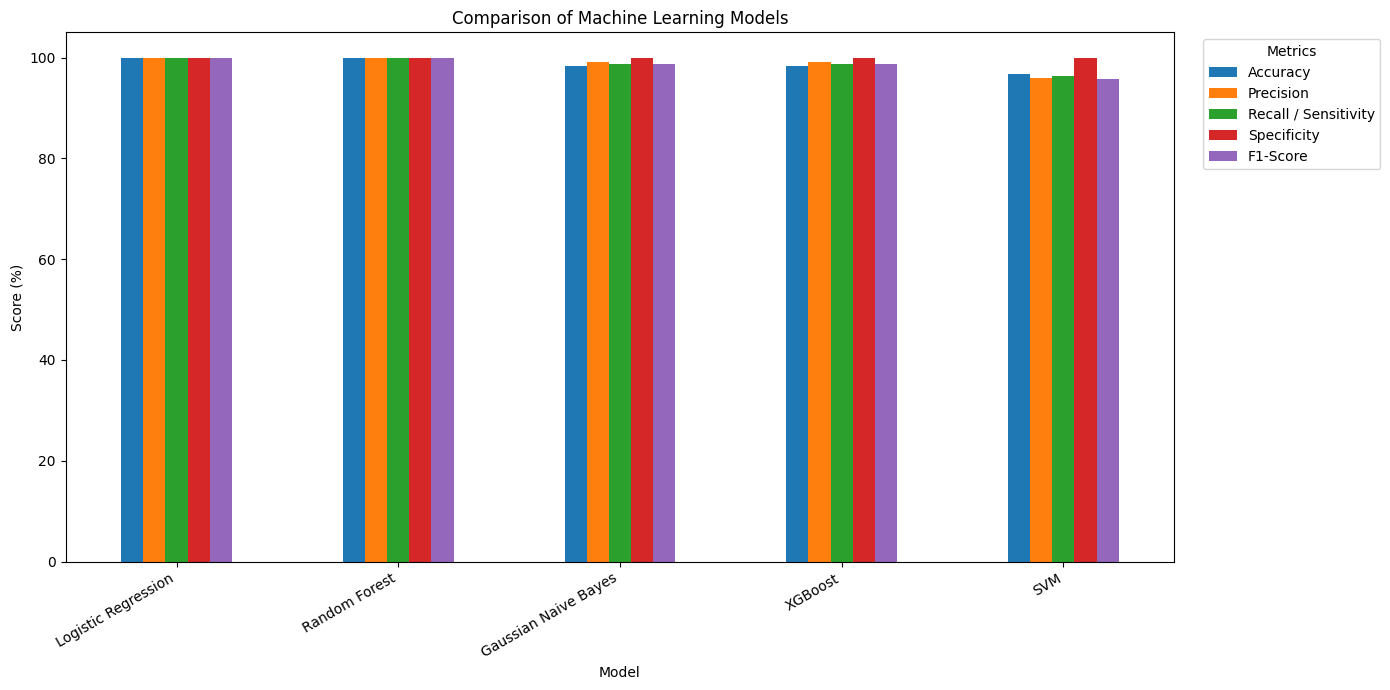

In [28]:
plot_df = results_df.set_index(
    "Model"
)[metric_columns]

ax = plot_df.plot(
    kind="bar",
    figsize=(14, 7)
)

plt.title(
    "Comparison of Machine Learning Models"
)

plt.xlabel("Model")
plt.ylabel("Score (%)")

plt.xticks(
    rotation=30,
    ha="right"
)

plt.ylim(0, 105)

plt.legend(
    title="Metrics",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()

plt.savefig(
    "results/model_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### model confusion matrix (best model)

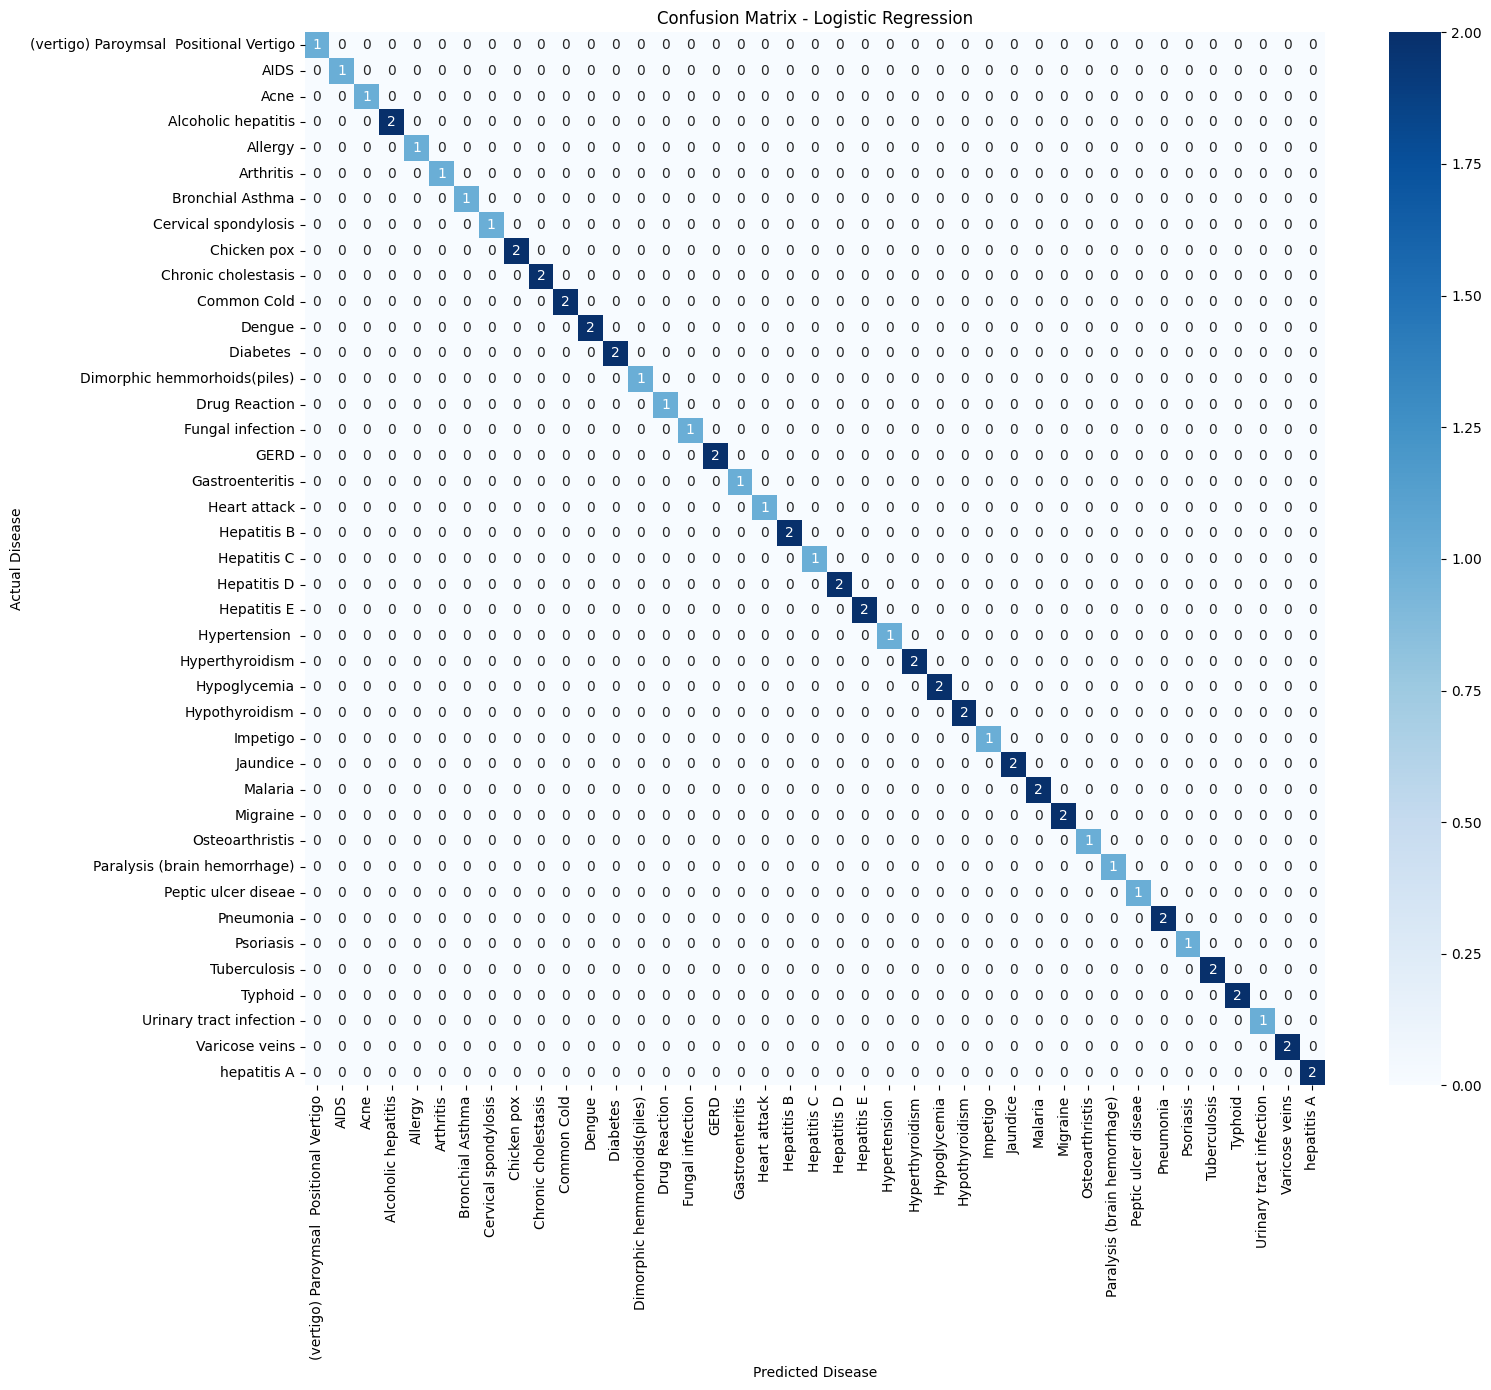

In [29]:
best_predictions = predictions[
    best_model_name
]

cm = confusion_matrix(
    y_test,
    best_predictions
)

plt.figure(figsize=(16, 14))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title(
    f"Confusion Matrix - {best_model_name}"
)

plt.xlabel("Predicted Disease")
plt.ylabel("Actual Disease")

plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.tight_layout()

plt.savefig(
    "results/confusion_matrix_best_model.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### model confusion matrix (all models)

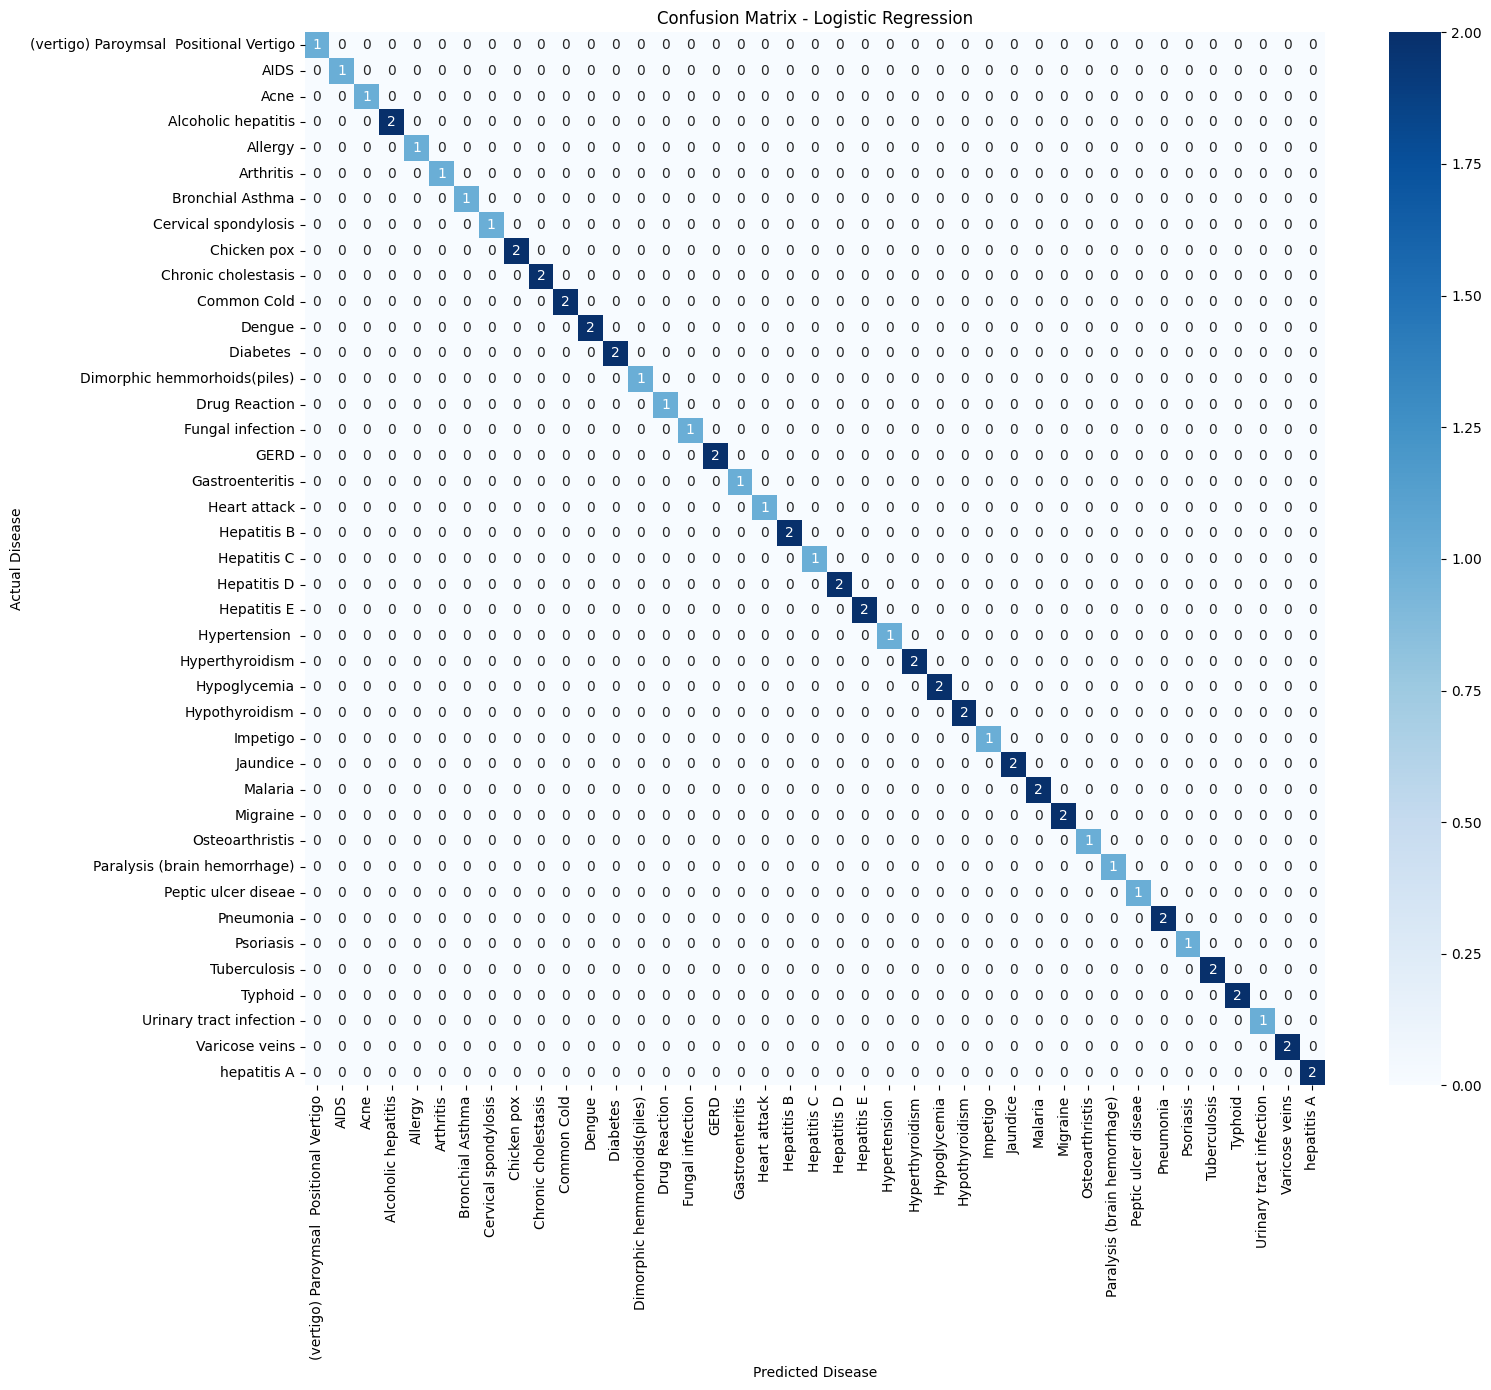

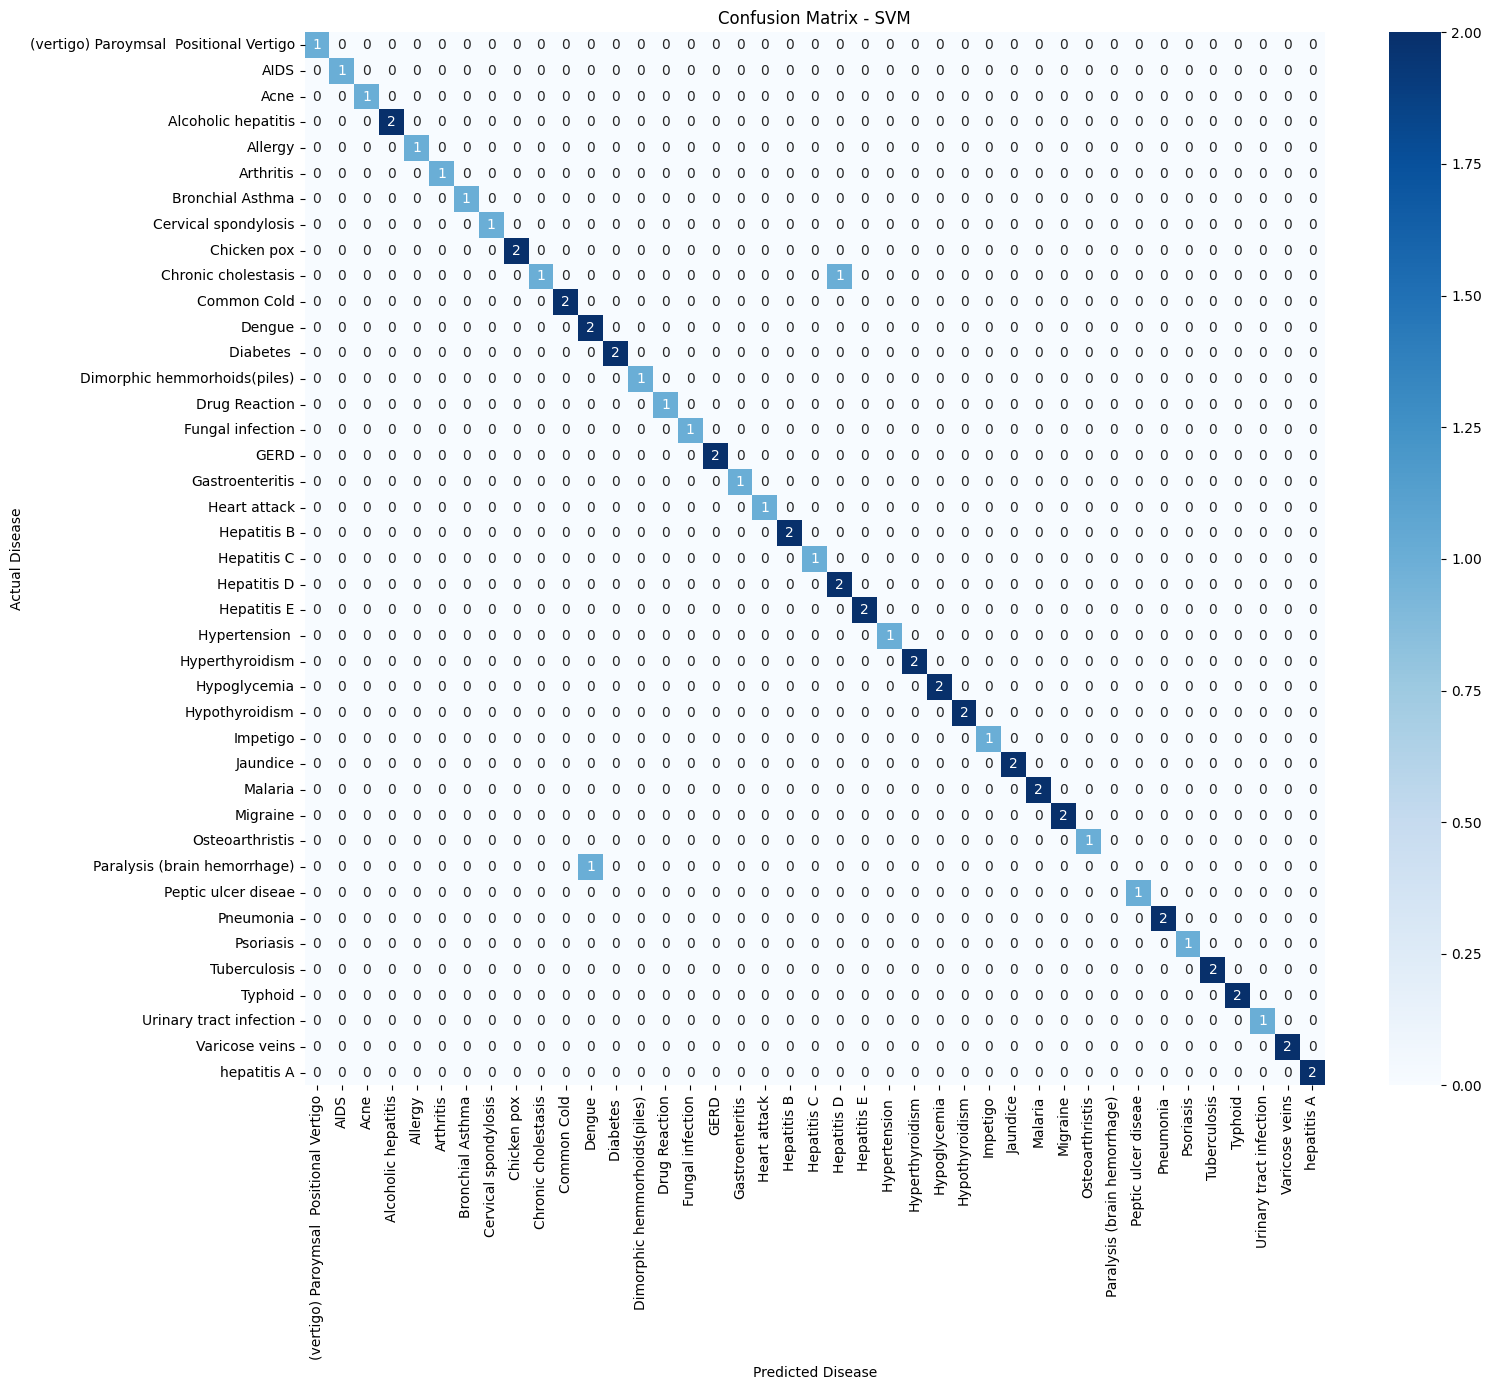

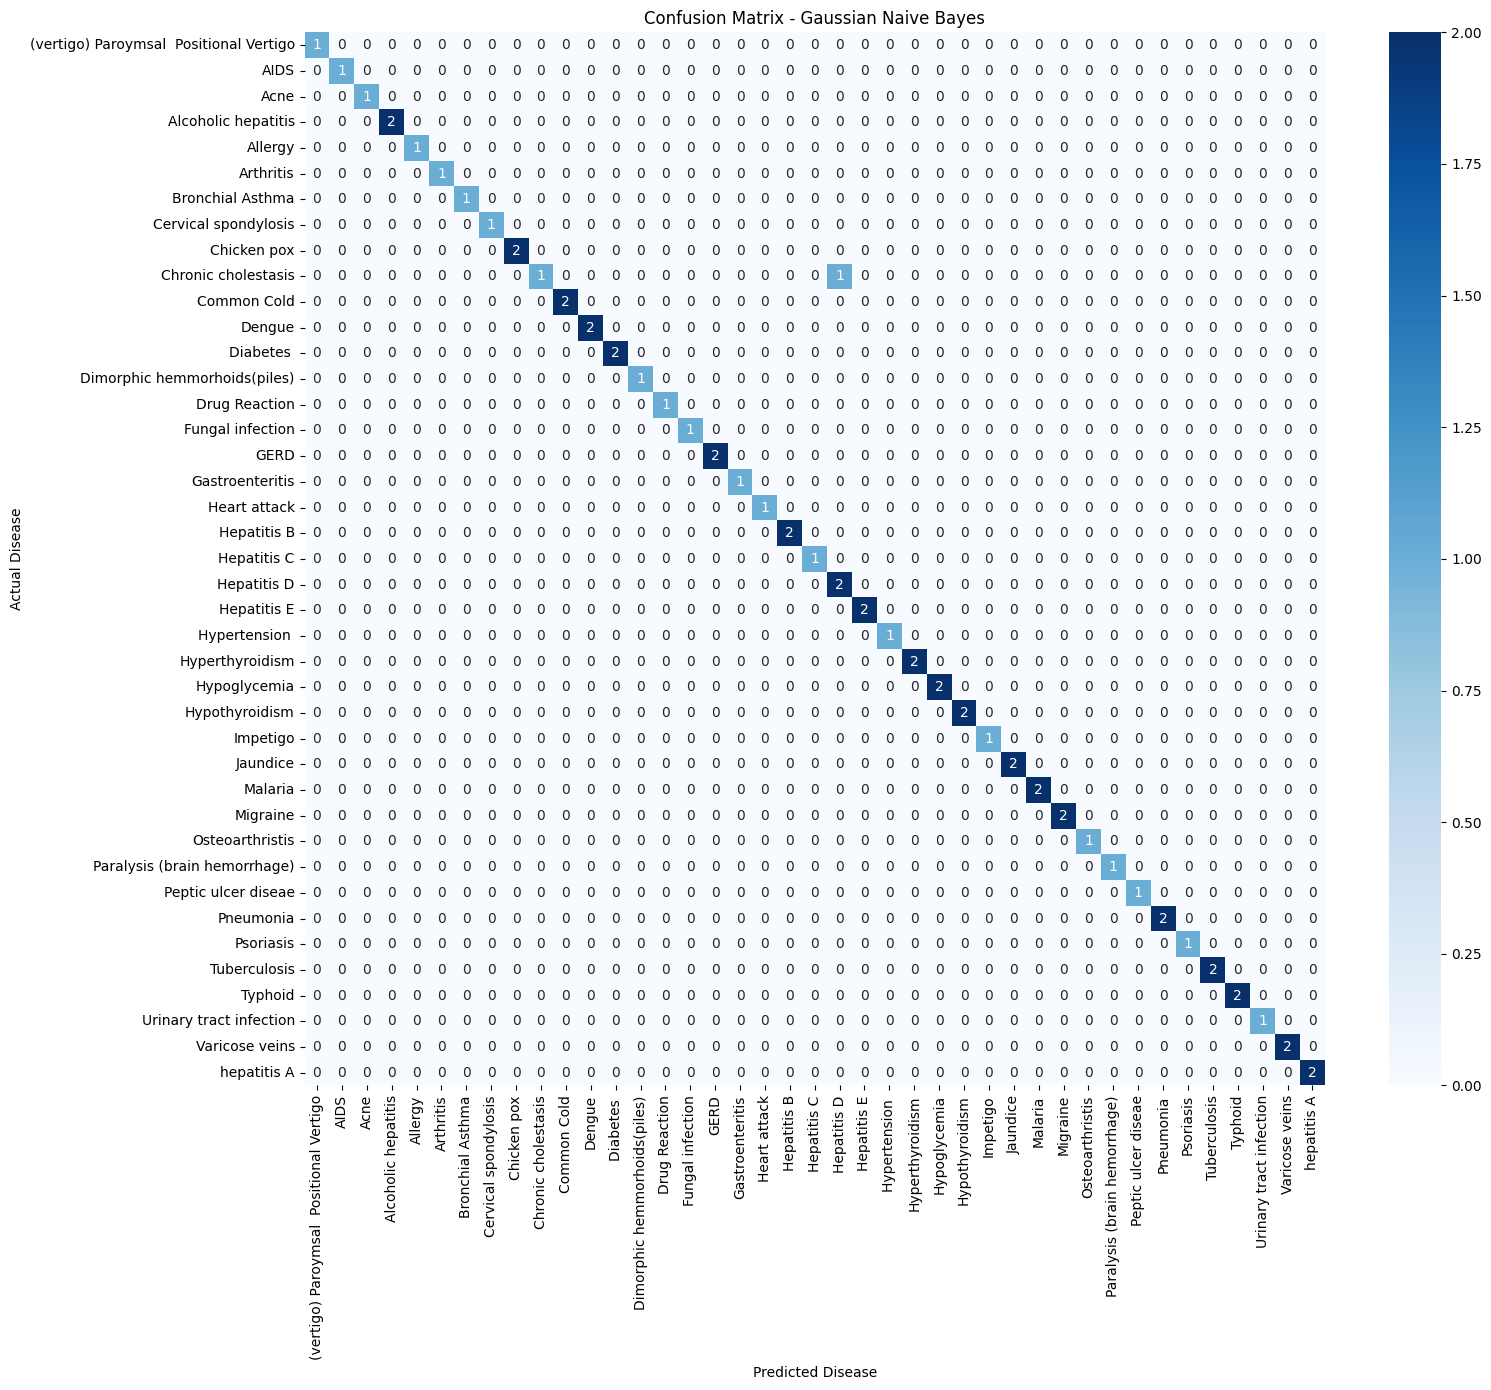

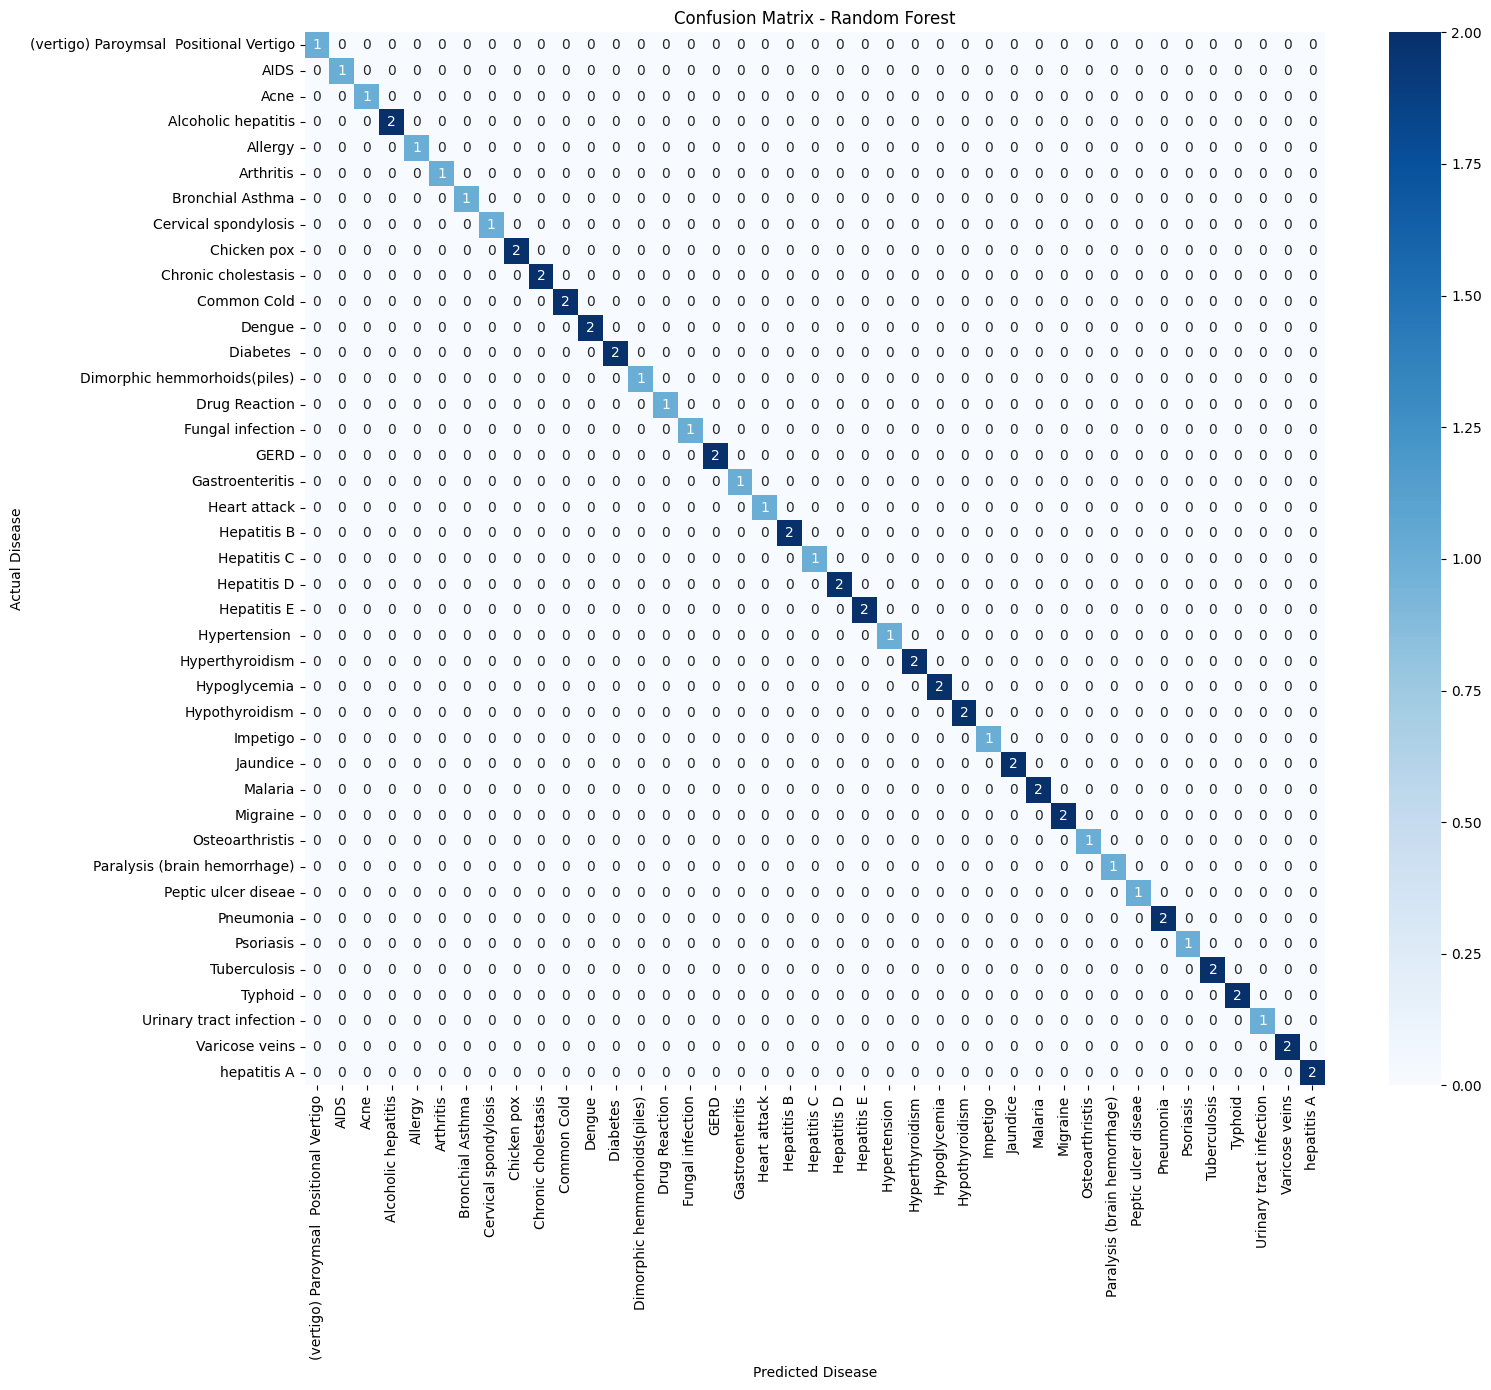

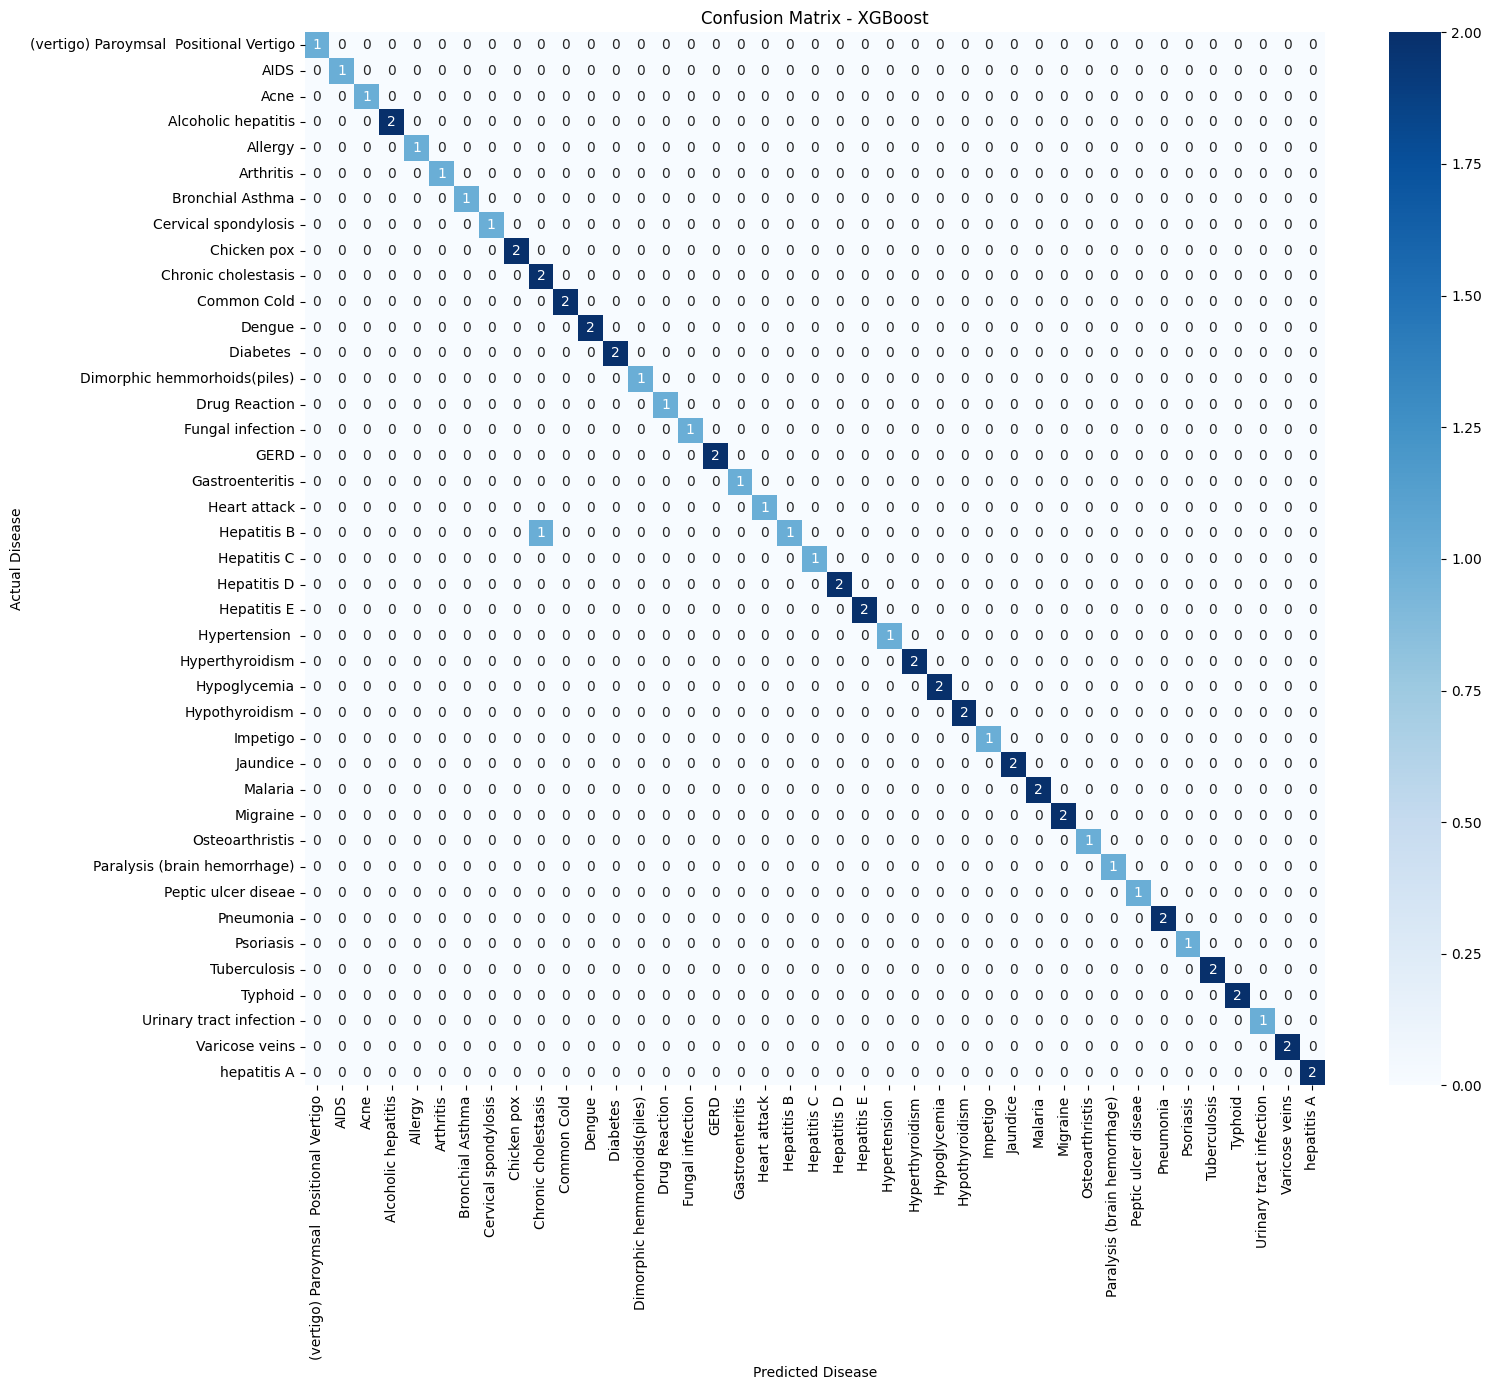

In [30]:
for name, y_pred in predictions.items():

    cm = confusion_matrix(
        y_test,
        y_pred
    )

    plt.figure(figsize=(16, 14))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=label_encoder.classes_,
        yticklabels=label_encoder.classes_
    )

    plt.title(
        f"Confusion Matrix - {name}"
    )

    plt.xlabel("Predicted Disease")
    plt.ylabel("Actual Disease")

    plt.xticks(rotation=90)
    plt.yticks(rotation=0)

    plt.tight_layout()

    safe_name = (
        name
        .lower()
        .replace(" ", "_")
    )

    plt.savefig(
        f"results/confusion_matrix_{safe_name}.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

### random forest feature

In [31]:
rf_model = trained_models[
    "Random Forest"
]

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = (
    feature_importance
    .sort_values(
        "Importance",
        ascending=False
    )
    .reset_index(drop=True)
)

print("Top 20 important symptoms:")

display(
    feature_importance.head(20)
)

Top 20 important symptoms:


,Feature,Importance
0,muscle_pain,0.020705
1,joint_pain,0.020063
2,fatigue,0.019084
3,vomiting,0.018270
4,high_fever,0.017512
5,yellowing_of_eyes,0.017472
6,itching,0.016881
7,mild_fever,0.016778
8,loss_of_appetite,0.016084
9,headache,0.015812


### plot feature importance

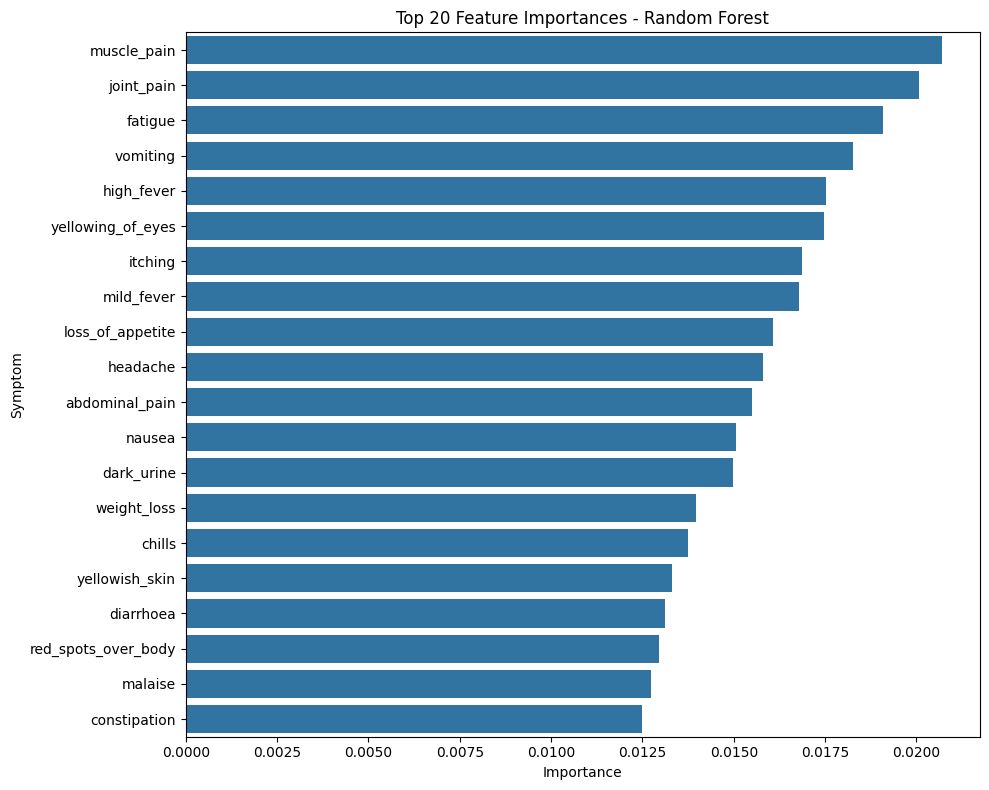

In [32]:
top_features = feature_importance.head(20)

plt.figure(figsize=(10, 8))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title(
    "Top 20 Feature Importances - Random Forest"
)

plt.xlabel("Importance")
plt.ylabel("Symptom")

plt.tight_layout()

plt.savefig(
    "results/random_forest_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### save feature importance

In [33]:
feature_importance.to_csv(
    "results/feature_importance.csv",
    index=False
)

print(
    "Saved: results/feature_importance.csv"
)

Saved: results/feature_importance.csv


### create symptom mapping

In [34]:
symptom_mapping = {
    symptom.lower().strip(): symptom
    for symptom in X.columns
}

print(
    "Number of available symptoms:",
    len(symptom_mapping)
)

Number of available symptoms: 134


### user disease prediction function

In [42]:
def predict_disease():

    print("\n" + "=" * 70)
    print("DISEASE PREDICTION USING MACHINE LEARNING")
    print("=" * 70)

    print("\nEnter symptoms separated by commas.")

    print("\nExample:")
    print("fever, itching, skin rash, headache, cough, sore throat (use multiple symptoms for better result)")

    user_input = input(
        "\nSymptoms: "
    )

    entered_symptoms = [
        symptom.lower().strip()
        for symptom in user_input.split(",")
        if symptom.strip()
    ]

    input_data = pd.DataFrame(
        0,
        index=[0],
        columns=X.columns
    )

    matched = []
    unmatched = []

    for symptom in entered_symptoms:

        if symptom in symptom_mapping:

            original_name = (
                symptom_mapping[symptom]
            )

            input_data.loc[
                0,
                original_name
            ] = 1

            matched.append(
                original_name
            )

        else:

            unmatched.append(
                symptom
            )

    print("\nMatched symptoms:")

    if matched:

        for symptom in matched:
            print("✓", symptom)

    else:
        print("None")

    if unmatched:

        print("\nUnrecognized symptoms:")

        for symptom in unmatched:
            print("✗", symptom)

    if not matched:

        print(
            "\nNo recognized symptoms were entered."
        )

        return

    prediction_encoded = (
        best_model.predict(
            input_data
        )
    )

    predicted_disease = (
        label_encoder
        .inverse_transform(
            prediction_encoded
        )[0]
    )

    print("\n" + "=" * 70)
    print("PREDICTED DISEASE")
    print("=" * 70)

    print(predicted_disease)

    if hasattr(
        best_model,
        "predict_proba"
    ):

        probabilities = (
            best_model
            .predict_proba(input_data)[0]
        )

        top_indices = np.argsort(
            probabilities
        )[::-1][:5]

        print("\nTop 5 Predictions:")

        for index in top_indices:

            disease = (
                label_encoder
                .classes_[index]
            )

            probability = (
                probabilities[index] * 100
            )

            print(
                f"{disease}: "
                f"{probability:.2f}%"
            )

    print("=" * 70)

### run the prediction function

In [43]:
predict_disease()


DISEASE PREDICTION USING MACHINE LEARNING

Enter symptoms separated by commas.

Example:
fever, itching, skin rash, headache, cough, sore throat (use multiple symptoms for better result)



Symptoms:  skin rash, cough



Matched symptoms:
✓ cough

Unrecognized symptoms:
✗ skin rash

PREDICTED DISEASE
Bronchial Asthma

Top 5 Predictions:
Bronchial Asthma: 11.47%
Hepatitis C: 5.89%
Malaria: 4.87%
Chronic cholestasis: 4.21%
GERD: 4.13%


### list generated results

In [37]:
print("Generated files:")
print("-" * 50)

for filename in sorted(
    os.listdir("results")
):

    print(filename)

Generated files:
--------------------------------------------------
confusion_matrix_best_model.png
confusion_matrix_gaussian_naive_bayes.png
confusion_matrix_logistic_regression.png
confusion_matrix_random_forest.png
confusion_matrix_svm.png
confusion_matrix_xgboost.png
feature_importance.csv
model_comparison.csv
model_comparison.png
random_forest_feature_importance.png
target_distribution.png


### final model summary

In [38]:
print("=" * 70)
print("FINAL MODEL PERFORMANCE")
print("=" * 70)

display(results_df)

print(
    f"\nBest Model: {best_model_name}"
)

print(
    f"Accuracy: "
    f"{results_df.iloc[0]['Accuracy']:.2f}%"
)

print(
    f"Precision: "
    f"{results_df.iloc[0]['Precision']:.2f}%"
)

print(
    f"Recall/Sensitivity: "
    f"{results_df.iloc[0]['Recall / Sensitivity']:.2f}%"
)

print(
    f"Specificity: "
    f"{results_df.iloc[0]['Specificity']:.2f}%"
)

print(
    f"F1-Score: "
    f"{results_df.iloc[0]['F1-Score']:.2f}%"
)

FINAL MODEL PERFORMANCE


,Model,Accuracy,Precision,Recall / Sensitivity,Specificity,F1-Score
0,Logistic Regression,100.000000,100.000000,100.000000,100.000000,100.000000
1,Random Forest,100.000000,100.000000,100.000000,100.000000,100.000000
2,Gaussian Naive Bayes,98.387097,99.186992,98.780488,99.959350,98.699187
3,XGBoost,98.387097,99.186992,98.780488,99.959350,98.699187
4,SVM,96.774194,95.934959,96.341463,99.918699,95.772358



Best Model: Logistic Regression
Accuracy: 100.00%
Precision: 100.00%
Recall/Sensitivity: 100.00%
Specificity: 100.00%
F1-Score: 100.00%
